# Modul Praktikum Klasifikasi Teks
## Part 1: Single-Label Classification & Part 2: Multi-Label Classification

## Part 1: Single-Label Classification

### 1. Import Required Libraries
We will first import necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. Load Train, Validation, and Test Datasets

In [3]:
# Load datasets
## TODO: Load dataset berdasarkan path dari file CSV kalian
##################

train_data = pd.read_csv("../data/train_preprocess.csv")
val_data = pd.read_csv("../data/valid_preprocess.csv")
test_data = pd.read_csv("../data/test_preprocess.csv")
##################

print('Train Data:', train_data.shape)
print('Validation Data:', val_data.shape)
print('Test Data:', test_data.shape)

Train Data: (810, 7)
Validation Data: (90, 7)
Test Data: (180, 7)


In [4]:
train_data.head()

,sentence,fuel,machine,others,part,price,service
0,Saya memakai Honda Jazz GK5 tahun 2014 ( perta...,neutral,neutral,positive,neutral,neutral,neutral
1,Avanza kenapa jadi boros bensin begini dah ah....,negative,neutral,neutral,neutral,neutral,neutral
2,"saran ku dan pengalaman ku , mending beli mobi...",positive,positive,neutral,neutral,neutral,neutral
3,Dari segi harga juga pajero lebih mahal 30 jut...,neutral,neutral,neutral,neutral,positive,neutral
4,Kalo menurut gw enak pajero si,neutral,neutral,positive,neutral,neutral,neutral


In [5]:
def plot_len_of_sentences(text_cols):
    comment_len = text_cols.len()

    # plot the distribution of comment lengths
    plt.figure(figsize=(8,4))
    sns.histplot(comment_len, kde=False, bins=50, color="red")
    plt.xlabel("Comment Length (Number of words)", fontsize=12)
    plt.ylabel("Number of Comments", fontsize=12)
    plt.title("Distribution of comment Lengths", fontsize=12)

    print("Average comment length:",int(sum(comment_len)/len(comment_len))," characters")

Average comment length: 84  characters


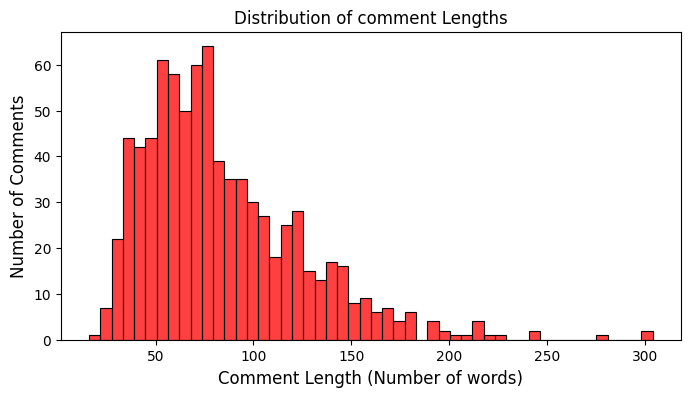

In [6]:
plot_len_of_sentences(train_data.sentence.str)

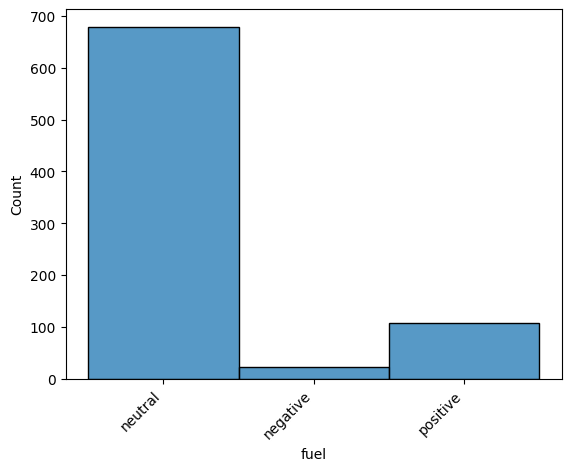

In [7]:
sns.histplot(train_data[train_data['fuel']!='']['fuel'])
plt.xticks(rotation=45, ha='right')
plt.show()

### 3. Text Preprocessing

In [8]:
# Define text preprocessing function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

# Apply preprocessing
## TODO: bagaimana cara menerapkan fungsi clean_text ke kolom 'sentence' pada train_data, val_data, dan test_data? 
###################
train_data['clean_text'] = train_data['sentence'].apply(clean_text)
val_data['clean_text'] = val_data['sentence'].apply(clean_text)
test_data['clean_text'] = test_data['sentence'].apply(clean_text)

###################

### 4. Feature Extraction & Training Single-Label Model

##### TFIDF with model : naive bayes, svm, KNN

In [10]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
# TF-IDF Vectorizer
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_data['clean_text'])
X_val = vectorizer.transform(val_data['clean_text'])
X_test = vectorizer.transform(test_data['clean_text'])

# Target labels
y_train = train_data['fuel']
y_val = val_data['fuel']
y_test = test_data['fuel']

param_grids = {
    ## TODO: Tambahkan model parameter grid minimal 5 model berbeda
    ##############
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0]
        }
    },
    'SVM': {
        'model': LinearSVC(),
        'params': {
            'C': [0.1, 1, 10]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['liblinear']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    }
    
    
    
    ##############
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}
results = {}

for model_name, config in param_grids.items():
    print(f"Running GridSearchCV for {model_name}...")
    
    ## TODO: bagaimana cara mendefinisikan GridSearchCV untuk model yang sudah ditentukan dengan parameter grid yang sudah dibuat?
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=kf,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)

    best_models[model_name] = grid.best_estimator_
    results[model_name] = grid.best_score_

    print(f"Best Params for {model_name}: {grid.best_params_}")
    print(f"Best Cross-Validation Accuracy: {grid.best_score_:.4f}\n")

Running GridSearchCV for Naive Bayes...
Best Params for Naive Bayes: {'alpha': 0.1}
Best Cross-Validation Accuracy: 0.8852

Running GridSearchCV for SVM...
Best Params for SVM: {'C': 10}
Best Cross-Validation Accuracy: 0.9642

Running GridSearchCV for KNN...
Best Params for KNN: {'n_neighbors': 7, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8852

Running GridSearchCV for Logistic Regression...
Best Params for Logistic Regression: {'C': 10, 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.9296

Running GridSearchCV for Decision Tree...
Best Params for Decision Tree: {'max_depth': None, 'min_samples_split': 5}
Best Cross-Validation Accuracy: 0.9654



### 5. Evaluation of Single-Label Model

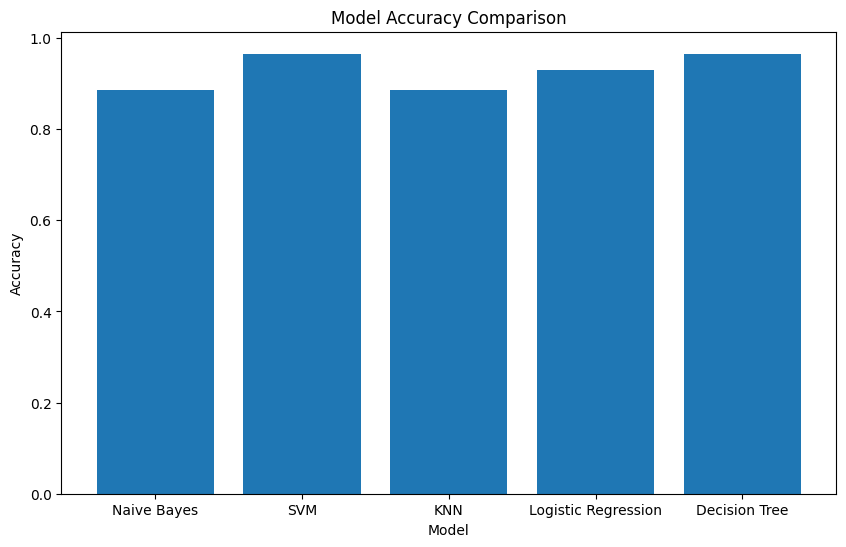

Naive Bayes Accuracy on Test Set: 0.8889
Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.10      0.18        10
     neutral       0.92      0.99      0.95       149
    positive       0.61      0.52      0.56        21

    accuracy                           0.89       180
   macro avg       0.84      0.54      0.57       180
weighted avg       0.89      0.89      0.87       180



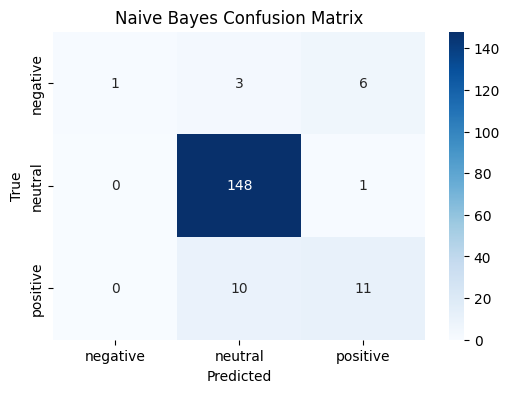

SVM Accuracy on Test Set: 0.9667
SVM Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        10
     neutral       0.98      0.99      0.98       149
    positive       0.86      0.86      0.86        21

    accuracy                           0.97       180
   macro avg       0.95      0.91      0.93       180
weighted avg       0.97      0.97      0.97       180



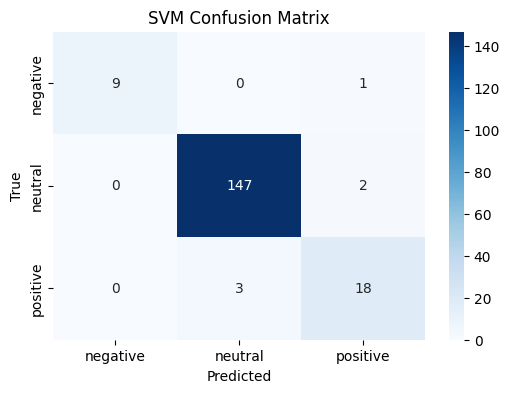

KNN Accuracy on Test Set: 0.9111
KNN Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.70      0.82        10
     neutral       0.92      0.99      0.95       149
    positive       0.75      0.43      0.55        21

    accuracy                           0.91       180
   macro avg       0.89      0.71      0.77       180
weighted avg       0.90      0.91      0.90       180



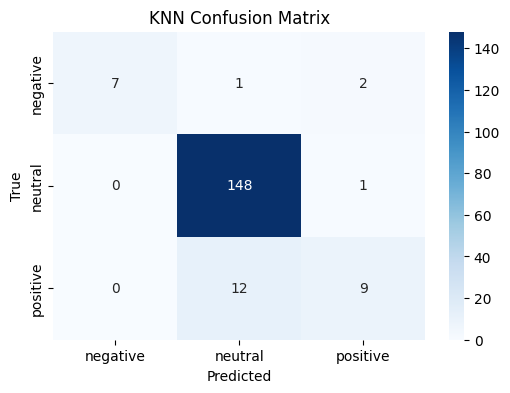

Logistic Regression Accuracy on Test Set: 0.9500
Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.70      0.82        10
     neutral       0.95      1.00      0.97       149
    positive       0.94      0.71      0.81        21

    accuracy                           0.95       180
   macro avg       0.96      0.80      0.87       180
weighted avg       0.95      0.95      0.95       180



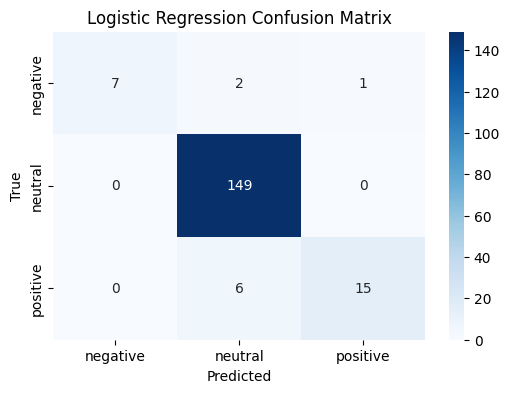

Decision Tree Accuracy on Test Set: 0.9833
Decision Tree Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90        10
     neutral       0.99      1.00      1.00       149
    positive       0.95      0.90      0.93        21

    accuracy                           0.98       180
   macro avg       0.95      0.93      0.94       180
weighted avg       0.98      0.98      0.98       180



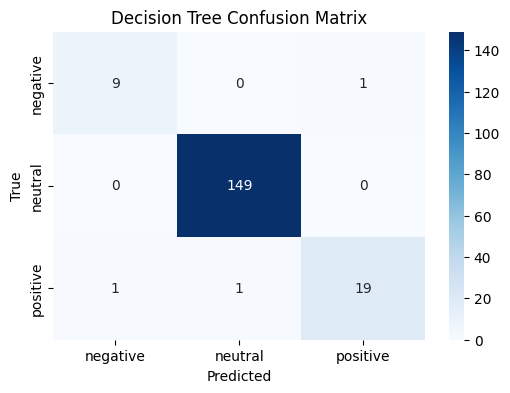

In [11]:
# plot every model accuracy
label = ['negative', 'neutral', 'positive']
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()


for model_name, model in best_models.items():
    model.fit(X_train, y_train)
    ## TODO: bagaimana cara memprediksi label untuk X_test menggunakan model yang sudah dilatih?
    y_pred = model.predict(X_test)

    print(f'{model_name} Accuracy on Test Set: {accuracy_score(y_test, y_pred):.4f}')

    print(f'{model_name} Classification Report:')
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,
                fmt='d', cmap='Blues', xticklabels=label, yticklabels=label)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [12]:
# predict the test set
best_model = best_models['SVM']
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
test_data['predicted'] = y_pred
test_data

,sentence,fuel,machine,others,part,price,service,clean_text,predicted
0,Terios paling gagah . Apalagi warna merah meta...,neutral,neutral,positive,positive,neutral,neutral,terios paling gagah apalagi warna merah metalic,neutral
1,"gue pakai mobilio . menurut gue , bener fun to...",neutral,neutral,positive,neutral,neutral,neutral,gue pakai mobilio menurut gue bener fun to d...,neutral
2,ya walaupun memiliki desain sporty kalau tingk...,neutral,neutral,negative,positive,neutral,neutral,ya walaupun memiliki desain sporty kalau tingk...,neutral
3,Xpander laku keras di pasar Indonesia .,neutral,neutral,positive,neutral,neutral,neutral,xpander laku keras di pasar indonesia,neutral
4,"Kalau mau segala enak pakai Avanza saja , mas .",neutral,neutral,positive,neutral,neutral,neutral,kalau mau segala enak pakai avanza saja mas,neutral
...,...,...,...,...,...,...,...,...,...
175,"kecewa sama bengkel suzuki bendan, garapan eng...",neutral,neutral,neutral,neutral,neutral,negative,kecewa sama bengkel suzuki bendan garapan engg...,neutral
176,"Formo baris kedua, kursinya jelek banget.",neutral,neutral,neutral,negative,neutral,neutral,formo baris kedua kursinya jelek banget,neutral
177,Setahu saya Suzuki Splash tidak dilengkapi den...,neutral,neutral,neutral,negative,neutral,neutral,setahu saya suzuki splash tidak dilengkapi den...,neutral
178,kalo dari eksterior nya saya lebih suka brio d...,neutral,neutral,neutral,negative,neutral,neutral,kalo dari eksterior nya saya lebih suka brio d...,neutral


In [13]:
correct = test_data[test_data['fuel'] == test_data['predicted']]
incorrect = test_data[test_data['fuel'] != test_data['predicted']]
print(f"Correct Predictions: {len(correct)}")
print(f"Incorrect Predictions: {len(incorrect)}")

Correct Predictions: 174
Incorrect Predictions: 6


## Part 2: Multi-Label Classification

### 1. Import Additional Libraries for Multi-Label Classification

In [14]:
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.metrics import multilabel_confusion_matrix

### 2. Preparing Multi-Label Data

In [15]:
# Define the labels for one-hot encoding
labels = ['fuel', 'machine', 'others', 'part', 'price', 'service']

# Apply one-hot encoding
train_encoded = pd.get_dummies(train_data, columns=labels, dtype=int)
val_encoded = pd.get_dummies(val_data, columns=labels, dtype=int)
test_encoded = pd.get_dummies(test_data, columns=labels, dtype=int)

In [16]:
train_encoded.head()

,sentence,clean_text,fuel_negative,fuel_neutral,fuel_positive,machine_negative,machine_neutral,machine_positive,others_negative,others_neutral,others_positive,part_negative,part_neutral,part_positive,price_negative,price_neutral,price_positive,service_negative,service_neutral,service_positive
0,Saya memakai Honda Jazz GK5 tahun 2014 ( perta...,saya memakai honda jazz gk tahun pertama mel...,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0
1,Avanza kenapa jadi boros bensin begini dah ah....,avanza kenapa jadi boros bensin begini dah ah ...,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0
2,"saran ku dan pengalaman ku , mending beli mobi...",saran ku dan pengalaman ku mending beli mobil...,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0
3,Dari segi harga juga pajero lebih mahal 30 jut...,dari segi harga juga pajero lebih mahal jutaa...,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0
4,Kalo menurut gw enak pajero si,kalo menurut gw enak pajero si,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0


In [17]:
# Define label columns for multi-label classification
label_columns = ['fuel_negative', 'fuel_neutral', 'fuel_positive', 'machine_negative', 'machine_neutral','machine_positive']  

y_train_multi = train_encoded[label_columns]
y_val_multi = val_encoded[label_columns]
y_test_multi = test_encoded[label_columns]

In [18]:
def plot_bar_graph(train_df,labels,title):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_axes([0,0,1,1])
    total_count = []
    for label in labels:
        total_count.append(len(train_df[train_df[label] == 1]))
    ax.bar(labels,total_count, color=['red', 'green', 'blue', 'purple', 'orange', 'yellow'])
    for i,data in enumerate(total_count):
        plt.text(i-.25, 
                data/total_count[i]+100, 
                total_count[i], 
                fontsize=12)
    plt.title(title)
    plt.xlabel('Labels')
    plt.ylabel('Number of comments')

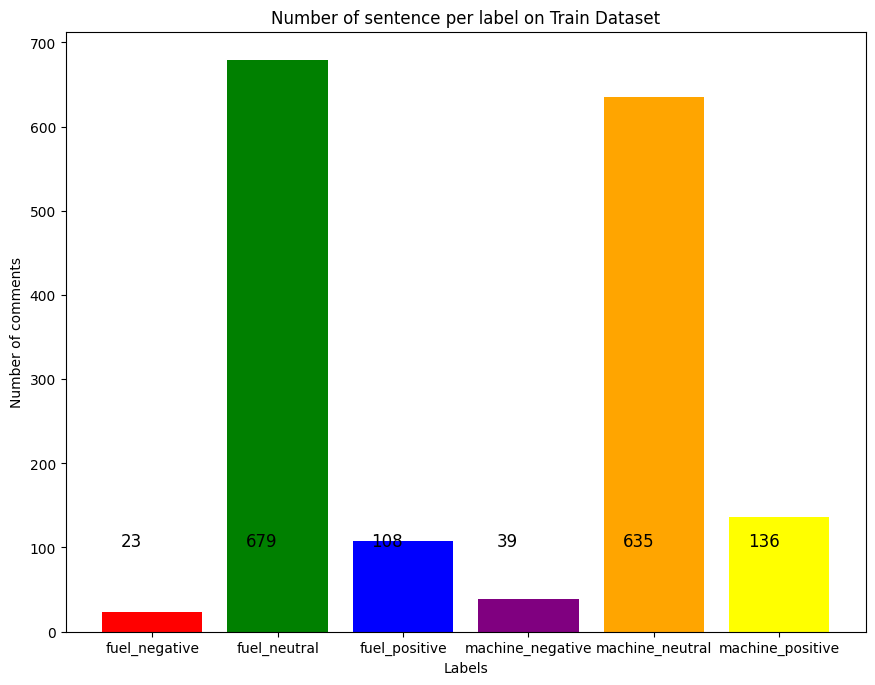

In [19]:
plot_bar_graph(y_train_multi,label_columns[:],'Number of sentence per label on Train Dataset')

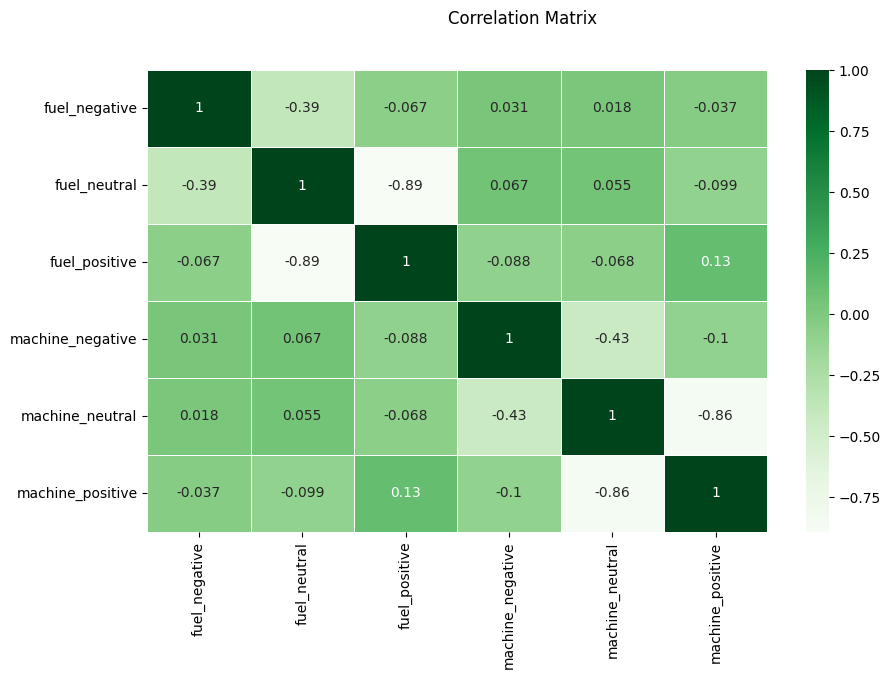

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Correlation Matrix')
sns.heatmap(y_train_multi.corr(numeric_only=True), annot=True, cmap="Greens", linewidths=.5, ax=ax);

### 3. Training Multi-Label Classification Model

Naive Bayes - Cross-Validation Accuracy: 0.6778 ± 0.0229
Naive Bayes Final Accuracy: 0.6444444444444445
Naive Bayes Classification Report:
                  precision    recall  f1-score   support

   fuel_negative       1.00      0.00      0.00        10
    fuel_neutral       0.88      1.00      0.94       149
   fuel_positive       1.00      0.10      0.17        21
machine_negative       1.00      0.00      0.00        14
 machine_neutral       0.82      1.00      0.90       137
machine_positive       1.00      0.03      0.07        29

       micro avg       0.85      0.80      0.83       360
       macro avg       0.95      0.35      0.35       360
    weighted avg       0.88      0.80      0.75       360
     samples avg       0.86      0.80      0.82       360

Naive Bayes Confusion Matrix:


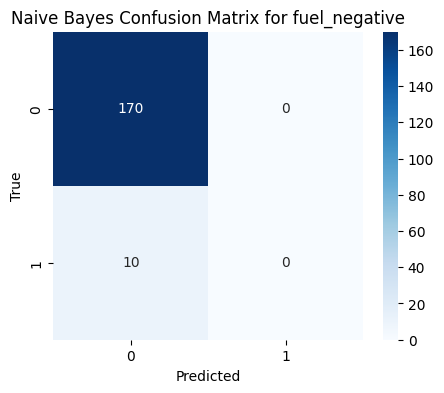

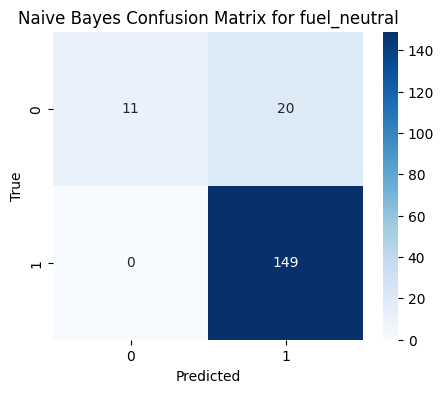

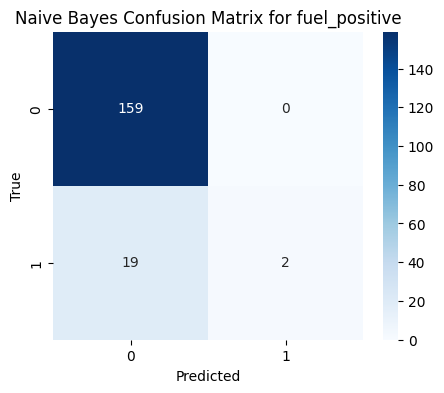

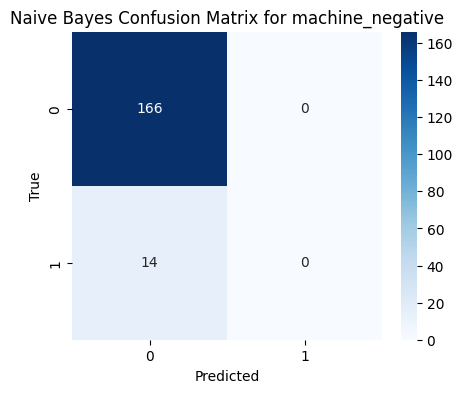

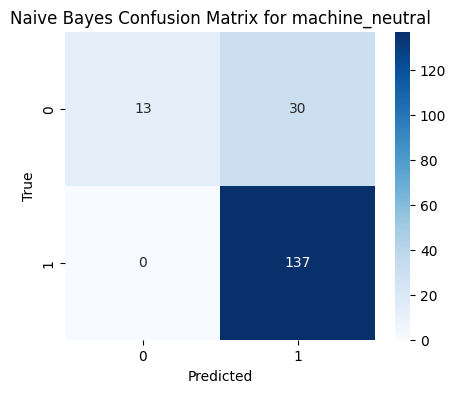

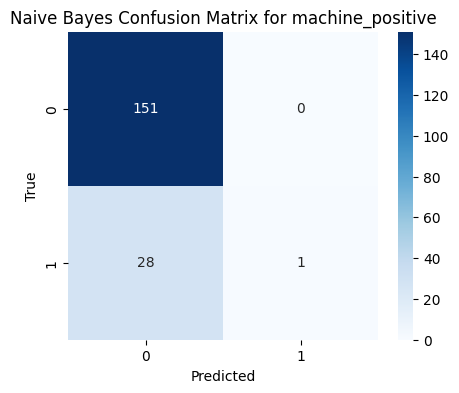

SVM - Cross-Validation Accuracy: 0.8099 ± 0.0163
SVM Final Accuracy: 0.8166666666666667
SVM Classification Report:
                  precision    recall  f1-score   support

   fuel_negative       1.00      0.80      0.89        10
    fuel_neutral       0.97      1.00      0.98       149
   fuel_positive       0.89      0.76      0.82        21
machine_negative       0.67      0.14      0.24        14
 machine_neutral       0.94      0.99      0.96       137
machine_positive       0.77      0.69      0.73        29

       micro avg       0.94      0.92      0.93       360
       macro avg       0.87      0.73      0.77       360
    weighted avg       0.93      0.92      0.91       360
     samples avg       0.94      0.92      0.92       360

SVM Confusion Matrix:


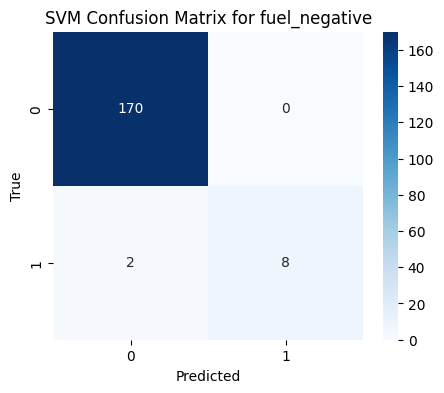

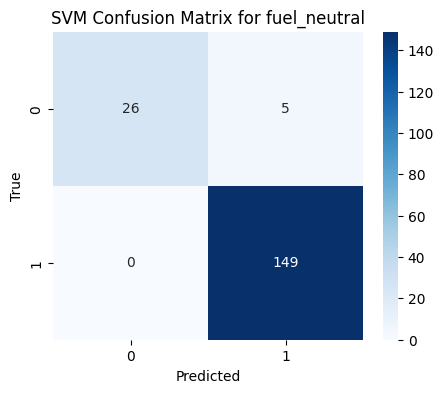

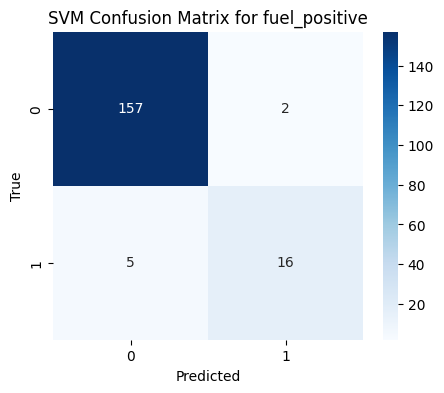

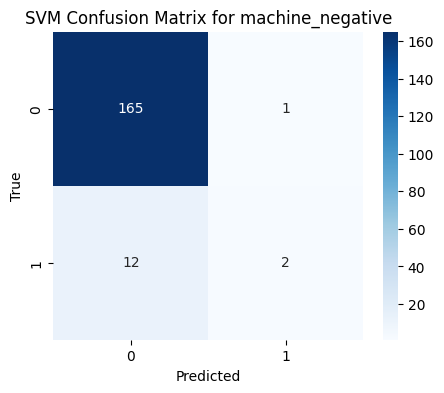

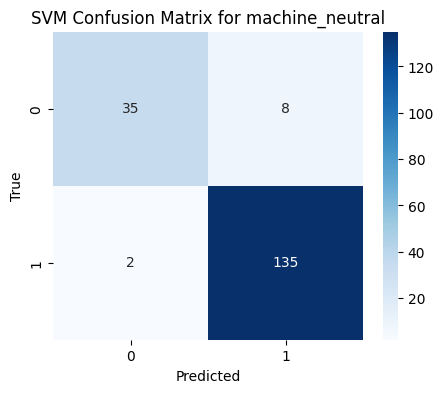

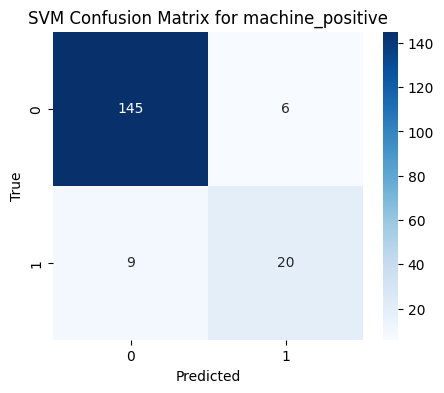

KNN - Cross-Validation Accuracy: 0.7333 ± 0.0283
KNN Final Accuracy: 0.6555555555555556
KNN Classification Report:
                  precision    recall  f1-score   support

   fuel_negative       1.00      0.30      0.46        10
    fuel_neutral       0.93      0.97      0.95       149
   fuel_positive       0.67      0.38      0.48        21
machine_negative       0.67      0.14      0.24        14
 machine_neutral       0.84      0.94      0.89       137
machine_positive       0.40      0.14      0.21        29

       micro avg       0.86      0.81      0.84       360
       macro avg       0.75      0.48      0.54       360
    weighted avg       0.83      0.81      0.80       360
     samples avg       0.86      0.81      0.83       360

KNN Confusion Matrix:


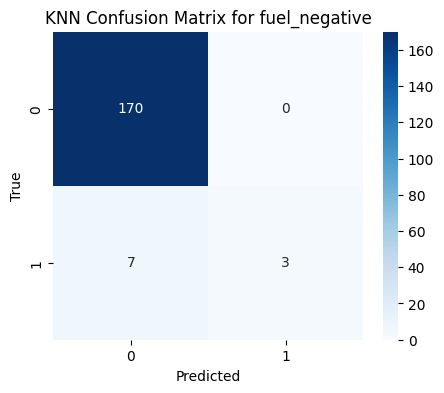

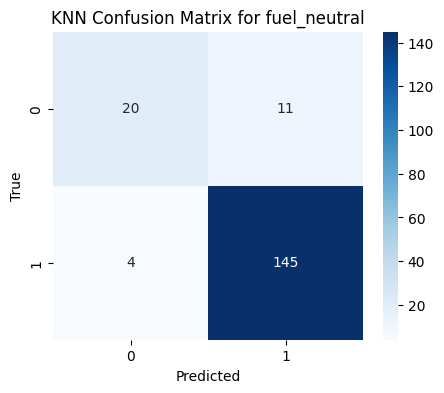

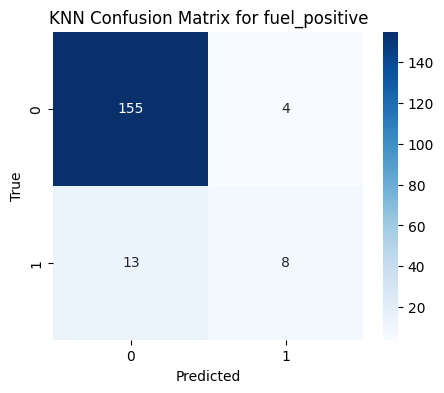

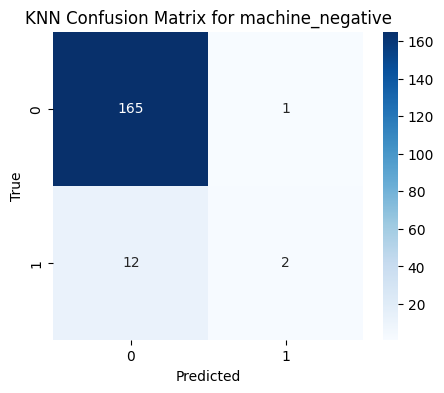

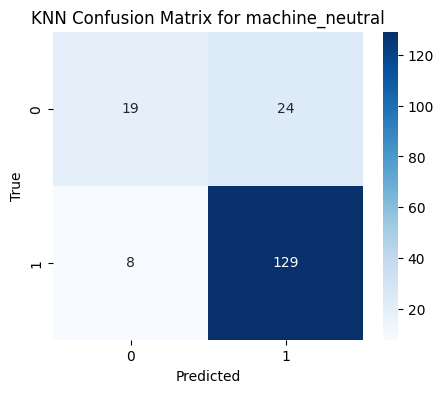

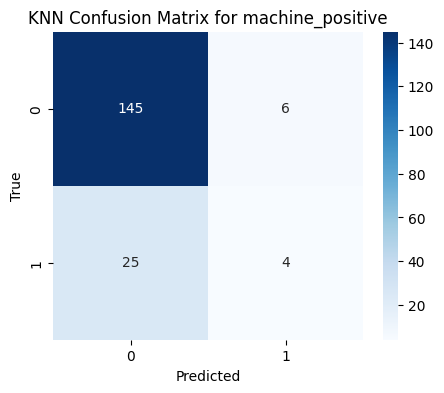

Logistic Regression - Cross-Validation Accuracy: 0.6988 ± 0.0226
Logistic Regression Final Accuracy: 0.6833333333333333
Logistic Regression Classification Report:
                  precision    recall  f1-score   support

   fuel_negative       1.00      0.00      0.00        10
    fuel_neutral       0.92      1.00      0.96       149
   fuel_positive       0.83      0.24      0.37        21
machine_negative       1.00      0.00      0.00        14
 machine_neutral       0.85      1.00      0.92       137
machine_positive       0.86      0.21      0.33        29

       micro avg       0.88      0.82      0.85       360
       macro avg       0.91      0.41      0.43       360
    weighted avg       0.89      0.82      0.79       360
     samples avg       0.89      0.82      0.85       360

Logistic Regression Confusion Matrix:


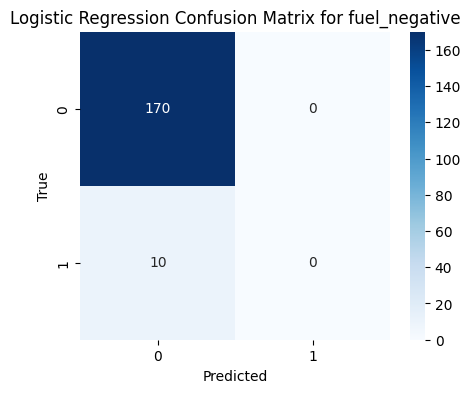

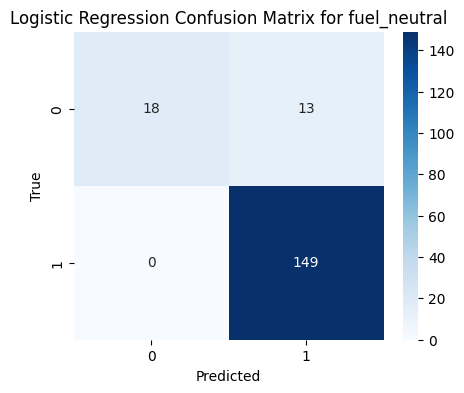

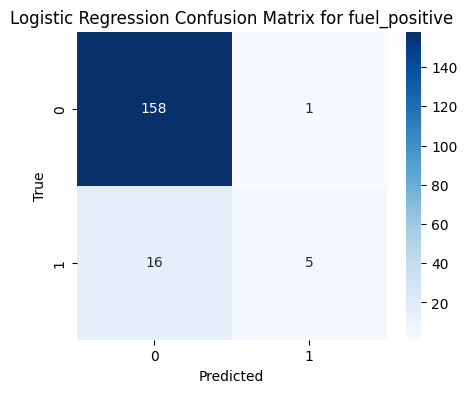

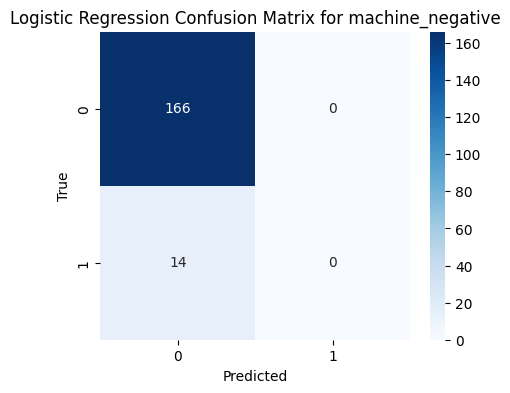

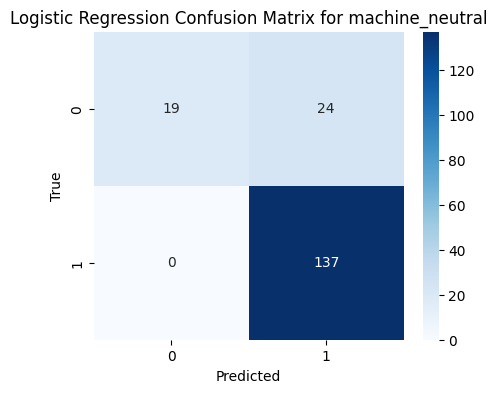

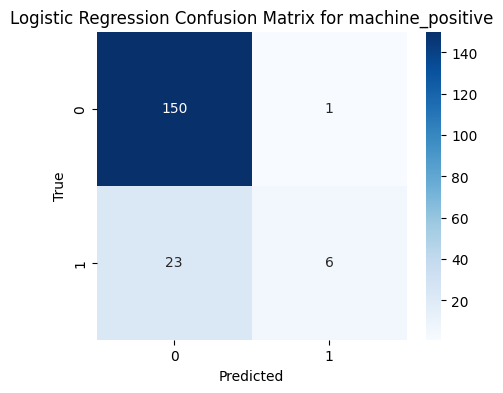

Decision Tree - Cross-Validation Accuracy: 0.8383 ± 0.0226
Decision Tree Final Accuracy: 0.8
Decision Tree Classification Report:
                  precision    recall  f1-score   support

   fuel_negative       0.89      0.80      0.84        10
    fuel_neutral       1.00      1.00      1.00       149
   fuel_positive       0.73      0.90      0.81        21
machine_negative       0.60      0.21      0.32        14
 machine_neutral       0.98      0.99      0.98       137
machine_positive       0.62      0.72      0.67        29

       micro avg       0.93      0.93      0.93       360
       macro avg       0.80      0.77      0.77       360
    weighted avg       0.93      0.93      0.92       360
     samples avg       0.94      0.93      0.93       360

Decision Tree Confusion Matrix:


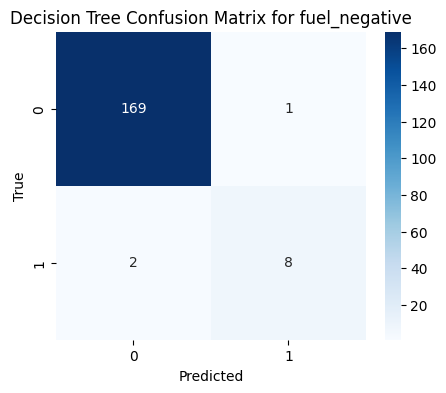

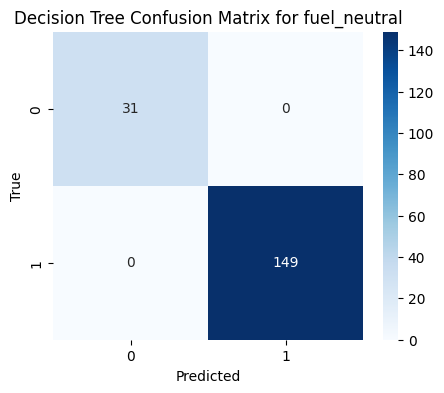

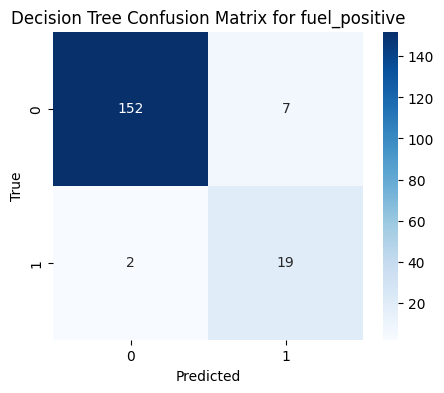

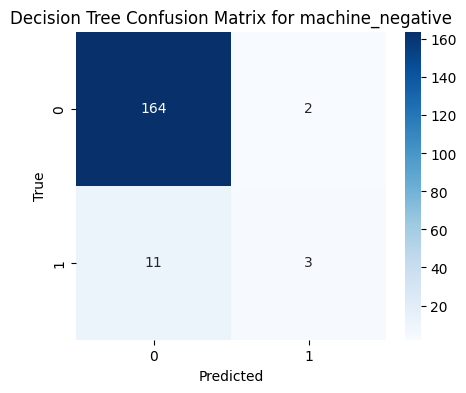

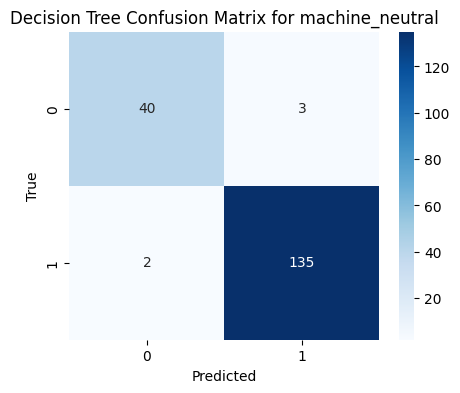

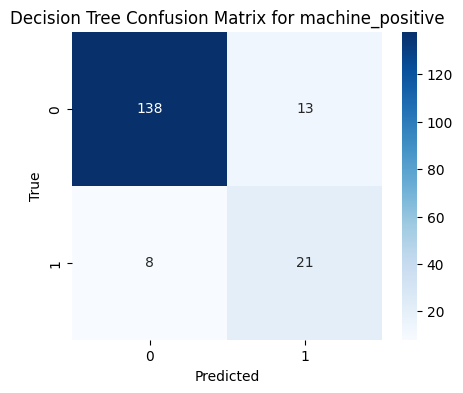

In [20]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.multiclass import OneVsRestClassifier
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

## TODO: bagaimana cara mendefinisikan KFold untuk multi-label classification ?
multi_kf = KFold(n_splits=5, shuffle=True, random_state=42)
result = {}

models = {
    #### TODO: Tambahkan minimal 5 model dan grid yang berbeda untuk multi-label classification
    ##############
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'SVM': LinearSVC(C=1.0),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42)
    
    ##############
}


for model_name, model in models.items():
    ## TODO: bagaimana cara membungkus model untuk multi-label classification ?
    wrapped_model = OneVsRestClassifier(model)

    scores = cross_val_score(
        wrapped_model, X_train, y_train_multi, cv=multi_kf, scoring='accuracy', n_jobs=-1)

    result[model_name] = scores
    print(f"{model_name} - Cross-Validation Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    wrapped_model.fit(X_train, y_train_multi)

    y_pred_multi = wrapped_model.predict(X_test)


    accuracy = accuracy_score(y_test_multi, y_pred_multi)
    print(f'{model_name} Final Accuracy:', accuracy)

    print(f'{model_name} Classification Report:')
    print(classification_report(y_test_multi, y_pred_multi,
          target_names=label_columns, zero_division=1))

    print(f'{model_name} Confusion Matrix:')
    mcm = multilabel_confusion_matrix(y_test_multi, y_pred_multi)

    for i, label in enumerate(label_columns):
        plt.figure(figsize=(5, 4))
        sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues')
        plt.title(f'{model_name} Confusion Matrix for {label}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

In [21]:

y_pred_test = {}
for model_name, model in models.items():
    ## TODO: bagaimana cara membungkus model untuk multi-label classification ?
    wrapped_model = OneVsRestClassifier(model)
    wrapped_model.fit(X_train, y_train_multi)
    ## TODO: bagaimana cara memprediksi label untuk X_test menggunakan model yang sudah dilatih?
    y_pred_test[model_name] = wrapped_model.predict(X_test)
y_pred_test





{'Naive Bayes': array([[0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        ...,
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 0, 1, 0, 1, 0]]),
 'SVM': array([[0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        ...,
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 1, 1, 0],
        [0, 0, 1, 0, 1, 0]]),
 'KNN': array([[0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        ...,
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 1, 0, 0],
        [0, 0, 1, 0, 1, 0]]),
 'Logistic Regression': array([[0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        ...,
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 0, 1, 0, 1, 0]]),
 'Decision Tree': array([[0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 1],
        ...,
        [0, 1, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [0, 0, 1, 0, 1, 0]])}